In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler,PolynomialFeatures
from sklearn.linear_model import LinearRegression

In [2]:
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing()
X = pd.DataFrame(housing.data, columns=housing.feature_names)
y= housing.target 

X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [3]:
# Load dataset
housing = fetch_california_housing()
X = pd.DataFrame(housing.data, columns=housing.feature_names)

# Convert target to Series with a name
y = pd.Series(housing.target, name="MedHouseValue")

# Combine features + target
df = pd.concat([X, y], axis=1)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MedInc         20640 non-null  float64
 1   HouseAge       20640 non-null  float64
 2   AveRooms       20640 non-null  float64
 3   AveBedrms      20640 non-null  float64
 4   Population     20640 non-null  float64
 5   AveOccup       20640 non-null  float64
 6   Latitude       20640 non-null  float64
 7   Longitude      20640 non-null  float64
 8   MedHouseValue  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


## Exploratory Data Analysis

In [5]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseValue
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [6]:
# Correlation with target
corr_with_target = df.corr()["MedHouseValue"].sort_values(ascending=False)
print(corr_with_target)


MedHouseValue    1.000000
MedInc           0.688075
AveRooms         0.151948
HouseAge         0.105623
AveOccup        -0.023737
Population      -0.024650
Longitude       -0.045967
AveBedrms       -0.046701
Latitude        -0.144160
Name: MedHouseValue, dtype: float64


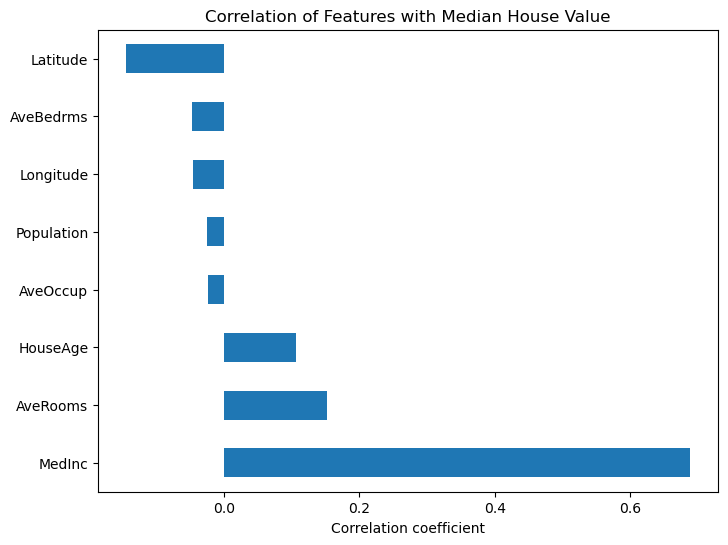

In [7]:
corr_with_target.drop("MedHouseValue").plot(kind="barh", figsize=(8,6))
plt.title("Correlation of Features with Median House Value")
plt.xlabel("Correlation coefficient")
plt.show()


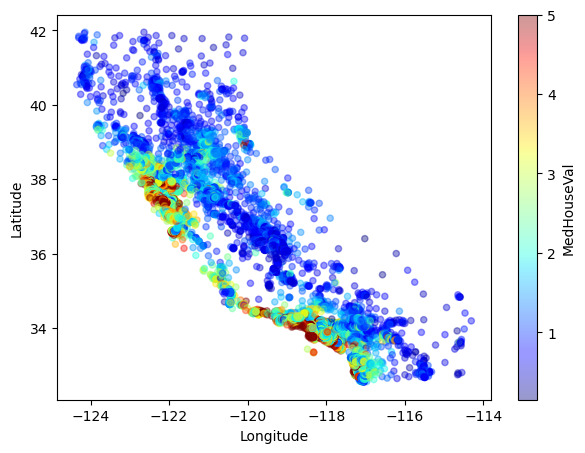

In [6]:
california = fetch_california_housing()

housing_df = pd.DataFrame(california.data, columns=california.feature_names)
housing_df['MedHouseVal'] = california.target

housing_df.plot(
    kind = "scatter",
    x='Longitude',
    y='Latitude',
    alpha=0.4,
    c='MedHouseVal',
    cmap=plt.get_cmap("jet"),
    colorbar=True,
    figsize=(7, 5),
)
plt.show()

## Data Preprocessing

In [8]:
# Split and Prepocess the Data

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features
# StandardScaler scales features to have mean 0 and std 1
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Model Selection and Training

In [9]:
#Using Linear Regression:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## Evaluation

In [10]:
# Evaluate the Model
from sklearn.metrics import mean_squared_error
y_pred = model.predict(X_test_scaled)
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse:.2f}")
# (lower is better, 0 is perfect)

Mean Squared Error: 0.56


In [11]:
# The coefficient of determination or R^2
model.score(X_test_scaled, y_test)
# higher is better, 1 is perfect

0.575787706032451

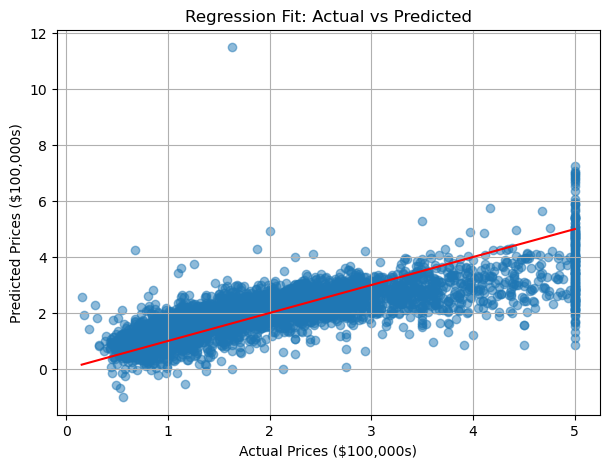

In [12]:

import matplotlib.pyplot as plt
# import seaborn as sns
plt.figure(figsize=(7, 5))
plt.scatter(x=y_test, y=y_pred, alpha=.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='r')
plt.xlabel("Actual Prices ($100,000s)")
plt.ylabel("Predicted Prices ($100,000s)")
plt.title("Regression Fit: Actual vs Predicted")
plt.grid(True)
plt.show()
# The regression fit compares actual vs. predicted values, with the red dashed line representing a perfect fit
# If points closely follow the line, predictions are accurate, but if a pattern (e.g, a curve) appears
# The red line is the ideal line — the closer your points are to this, the better

## Prediction

In [13]:
# Using the first model, result should be the same
def predict_house_price2(MedInc, HouseAge, AveRooms, AveBedrms,
     Population, AveOccup, Latitude, Longitude):
    
     # Prepare input as a 2D array (one row, 8 features)
     sample = [[MedInc, HouseAge, AveRooms, AveBedrms,
     Population, AveOccup, Latitude, Longitude]]
     sample = scaler.transform(sample)
     predicted_price = model.predict(sample)[0]
     return f"Estimated House Price: ${predicted_price * 100_000:,.2f}"

In [14]:
predict_house_price2(MedInc=8.3, HouseAge=41.0, AveRooms=6.0, AveBedrms=1,
Population=980, AveOccup=2.5, Latitude=37.5, Longitude=-122.3)

C:\Users\USER\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


'Estimated House Price: $443,209.67'

## Parameter Tuning

In [15]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge

param_grid = {'alpha': [0.1, 1.0, 10.0, 100.0]}
ridge = Ridge()
grid_search = GridSearchCV(ridge, param_grid, cv=5)
grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)

Best Parameters: {'alpha': 10.0}
Best Score: 0.6114911963572343


## Using Pipeline

In [13]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

pipeline.fit(X_train, y_train)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None


In [14]:
# Evaluate the Model
y_pred = pipeline.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse:.2f}")

Mean Squared Error: 0.56


In [15]:
pipeline.score(X_test, y_test)

0.575787706032451

In [11]:
Input=[('scale',StandardScaler()),('polynomial', PolynomialFeatures(include_bias=False)),('model',LinearRegression())]

In [22]:
pipe=Pipeline(Input)
pipe.fit(X_train,y_train)
y_pred= pipe.predict(X_test)
r2= pipe.score(X_test, y_test)
print(r2)

0.6456819729262278


In [20]:
mse = mean_squared_error(y_test, y_pred)
mse

0.5558915986952442

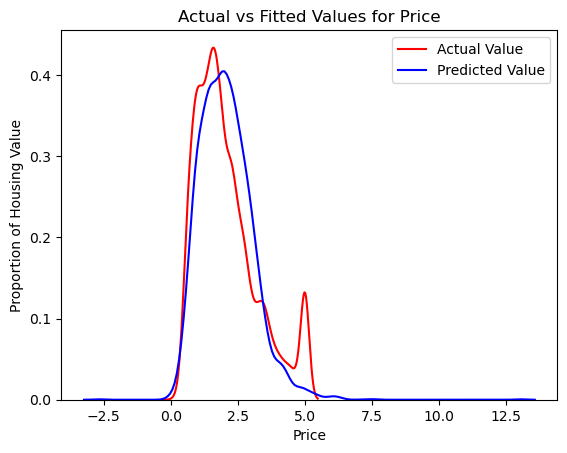

In [25]:
# Checking for how well the model performed

ax1 = sns.kdeplot(df['MedHouseValue'], color="r", label ="Actual Value")

sns.kdeplot(y_pred, color="b", label = "Fitted Values", ax=ax1)

plt.title('Actual vs Fitted Values for Price')
plt.xlabel('Price')
plt.ylabel('Proportion of Housing Value')
plt.legend(['Actual Value', 'Predicted Value'])
plt.show()